In [ ]:
!pip install ultralytics --upgrade --quiet

import os
import zipfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 100.1 MB/s eta 0:00:00


In [ ]:
# downloading VOC 2012 dataset
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar

# extract
!tar -xf VOCtrainval_11-May-2012.tar


--2025-05-24 09:32:50--  http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.152
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.152|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1999639040 (1.9G) [application/x-tar]
Saving to: ‘VOCtrainval_11-May-2012.tar’

VOCtrainval_11-May- 100%[===================>]   1.86G  15.5MB/s    in 2m 6s   

2025-05-24 09:34:57 (15.1 MB/s) - ‘VOCtrainval_11-May-2012.tar’ saved [1999639040/1999639040]



In [ ]:
import xml.etree.ElementTree as ET
from tqdm import tqdm

# VOC class
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable",
    "dog", "horse", "motorbike", "person", "pottedplant",
    "sheep", "sofa", "train", "tvmonitor"
]

CLASS_TO_ID = {cls: i for i, cls in enumerate(VOC_CLASSES)}

def convert_voc_to_yolo(voc_ann_path, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    for xml_file in tqdm(os.listdir(voc_ann_path)):
        if not xml_file.endswith(".xml"):
            continue

        xml_path = os.path.join(voc_ann_path, xml_file)
        tree = ET.parse(xml_path)
        root = tree.getroot()

        image_w = int(root.find("size/width").text)
        image_h = int(root.find("size/height").text)

        lines = []
        for obj in root.findall("object"):
            cls_name = obj.find("name").text
            if cls_name not in CLASS_TO_ID:
                continue

            cls_id = CLASS_TO_ID[cls_name]
            bbox = obj.find("bndbox")
            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)


            # YOLO format: cx, cy, w, h (normalized)
            cx = ((xmin + xmax) / 2) / image_w
            cy = ((ymin + ymax) / 2) / image_h
            w = (xmax - xmin) / image_w
            h = (ymax - ymin) / image_h

            lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        # Save .txt
        txt_filename = xml_file.replace(".xml", ".txt")
        with open(os.path.join(output_dir, txt_filename), "w") as f:
            f.write("\n".join(lines))

voc_ann_path = "VOCdevkit/VOC2012/Annotations"
yolo_labels_output_dir = "VOCdevkit/VOC2012/labels"
convert_voc_to_yolo(voc_ann_path, yolo_labels_output_dir)


100%|██████████| 17125/17125 [00:03<00:00, 4428.07it/s]


In [ ]:
from shutil import copyfile

os.makedirs("datasets/VOC/images/train", exist_ok=True)
os.makedirs("datasets/VOC/images/val", exist_ok=True)
os.makedirs("datasets/VOC/labels/train", exist_ok=True)
os.makedirs("datasets/VOC/labels/val", exist_ok=True)

# train/val
with open("VOCdevkit/VOC2012/ImageSets/Main/train.txt") as f:
    train_ids = [line.strip() for line in f.readlines()]

with open("VOCdevkit/VOC2012/ImageSets/Main/val.txt") as f:
    val_ids = [line.strip() for line in f.readlines()]

for image_id in tqdm(train_ids):
    img_src = f"VOCdevkit/VOC2012/JPEGImages/{image_id}.jpg"
    lbl_src = f"VOCdevkit/VOC2012/labels/{image_id}.txt"

    copyfile(img_src, f"datasets/VOC/images/train/{image_id}.jpg")
    copyfile(lbl_src, f"datasets/VOC/labels/train/{image_id}.txt")

for image_id in tqdm(val_ids):
    img_src = f"VOCdevkit/VOC2012/JPEGImages/{image_id}.jpg"
    lbl_src = f"VOCdevkit/VOC2012/labels/{image_id}.txt"

    copyfile(img_src, f"datasets/VOC/images/val/{image_id}.jpg")
    copyfile(lbl_src, f"datasets/VOC/labels/val/{image_id}.txt")


100%|██████████| 5823/5823 [00:05<00:00, 1049.41it/s]


In [ ]:
yaml_content = """
path: datasets/VOC
train: images/train
val: images/val
nc: 20
names: [
  'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
  'bus', 'car', 'cat', 'chair', 'cow',
  'diningtable', 'dog', 'horse', 'motorbike', 'person',
  'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
"""

with open("VOC.yaml", "w") as f:
    f.write(yaml_content.strip())


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os

train_path = "datasets/VOC/images/train"
val_path = "datasets/VOC/images/val"

train_files = {os.path.splitext(f)[0] for f in os.listdir(train_path) if f.endswith((".jpg", ".png"))}
val_files = {os.path.splitext(f)[0] for f in os.listdir(val_path) if f.endswith((".jpg", ".png"))}

duplicates = train_files.intersection(val_files)

if duplicates:
    print(f"❌ same images in train և val sets. count՝ {len(duplicates)}")
    print("Examples:", list(duplicates)[:5])
else:
    print("✅ there are not duplicates in train and val sets")

✅ there are not duplicates in train and val sets


In [ ]:
model = YOLO("yolov8m.pt")

# train/fine-tune Pascal VOC dataset
results = model.train(
    data="VOC.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="yolov8m.pt",
    workers=2,
    patience=50,
    save=True,
    val=True,
    device=0,
    flipud=0.1,
    fliplr=0.5,
    mixup=0.0,
    mosaic= 0.75,
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.4,
    lr0=0.003,
    iou=0.45 ,
    label_smoothing=0.1,
    copy_paste=0.0,
    momentum= 0.9,
    weight_decay=0.0005


)


100%|██████████| 49.7M/49.7M [00:00<00:00, 368MB/s]


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in in the future.
Ultralytics 8.3.143 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VOC.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.45, keras=False, kobj=1.0, line_width=None, lr0=0.003, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.9, mosaic=0.75, multi_scale=False, name=yolov8m.pt, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

100%|██████████| 755k/755k [00:00<00:00, 83.7MB/s]

Overriding model.yaml nc=80 with nc=20

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytic

  8                  -1  2   3985920  ultralytics.nn.modules.block.C2f             [576, 576, 2, True]           
  9                  -1  1    831168  ultralytics.nn.modules.block.SPPF            [576, 576, 5]                 
 10                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 11             [-1, 6]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 12                  -1  2   1993728  ultralytics.nn.modules.block.C2f             [960, 384, 2]                 
 13                  -1  1         0  torch.nn.modules.upsampling.Upsample         [None, 2, 'nearest']          
 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  2    517632  ultralytics.nn.modules.block.C2f             [576, 192, 2]                 
 16                  -1  1    332160  ultralytics.nn.modules.conv.Conv             [192,

...

      50/50      6.34G      0.557     0.3942     0.9925          7        640: 100%|██████████| 358/358 [03:04<00:00,  1.94it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 182/182 [01:07<00:00,  2.69it/s]

                   all       5823      15787      0.824      0.693      0.768      0.593



50 epochs completed in 3.621 hours.
Optimizer stripped from runs/detect/yolov8m.pt/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/yolov8m.pt/weights/best.pt, 52.0MB

Validating runs/detect/yolov8m.pt/weights/best.pt...
Ultralytics 8.3.143 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,851,340 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 182/182 [01:10<00:00,  2.56it/s]


                   all       5823      15787      0.823      0.692      0.769      0.594
             aeroplane        348        484      0.901      0.762      0.832      0.683
               bicycle        290        380      0.836       0.75       0.81      0.634
                  bird        374        629      0.887      0.671      0.776      0.583
                  boat        252        491      0.725      0.532      0.632        0.4
                bottle        369        733      0.796      0.514      0.623       0.44
                   bus        211        320      0.866      0.809      0.873      0.758
                   car        608       1173      0.855      0.732      0.811      0.608
                   cat        544        618      0.915      0.843      0.916      0.785
                 chair        642       1449      0.753      0.523      0.623      0.445
                   cow        154        347      0.786      0.697      0.773      0.601
           diningtabl

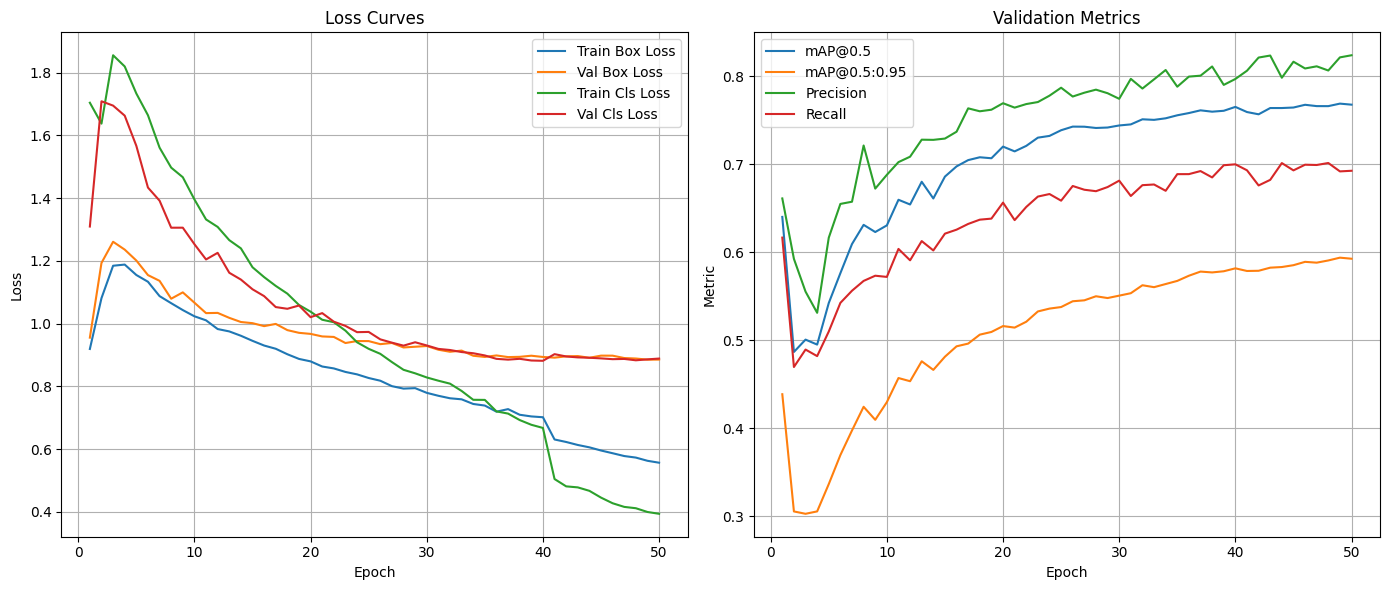

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('runs/detect/yolov8m.pt/results.csv')

df.columns = df.columns.str.strip()

epochs = df['epoch']
train_box = df['train/box_loss']
val_box = df['val/box_loss']
train_cls = df['train/cls_loss']
val_cls = df['val/cls_loss']
map50 = df['metrics/mAP50(B)']
map5095 = df['metrics/mAP50-95(B)']
precision = df['metrics/precision(B)']
recall = df['metrics/recall(B)']

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(epochs, train_box, label='Train Box Loss')
ax1.plot(epochs, val_box, label='Val Box Loss')
ax1.plot(epochs, train_cls, label='Train Cls Loss')
ax1.plot(epochs, val_cls, label='Val Cls Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# mAP, precision, recall
ax2.plot(epochs, map50, label='mAP@0.5')
ax2.plot(epochs, map5095, label='mAP@0.5:0.95')
ax2.plot(epochs, precision, label='Precision')
ax2.plot(epochs, recall, label='Recall')
ax2.set_title('Validation Metrics')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Metric')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()
